In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from io import StringIO

warnings.filterwarnings("ignore")

# exception handling for requests,xgboost,shap and scikit learn#
try:
    import requests
    HAS_REQUESTS = True
except ImportError:
    HAS_REQUESTS = False

try:
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
    from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix
    from sklearn.preprocessing import LabelEncoder
    HAS_SKLEARN = True
except ImportError:
    raise ImportError("scikit-learn not found")

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not found.")

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("SHAP not found. ")

# defining plot style#
plt.style.use("dark_background")
COLORS = {
    "bg":       "#0a0e1a",
    "panel":    "#111827",
    "border":   "#1e2d4a",
    "lr":       "#22c55e",
    "rf":       "#60a5fa",
    "xgb":      "#f59e0b",
    "bad":      "#ef4444",
    "good":     "#22c55e",
    "text":     "#e2e8f0",
    "subtext":  "#94a3b8",
    "muted":    "#475569",
}
RC = {
    "figure.facecolor":  COLORS["bg"],
    "axes.facecolor":    COLORS["panel"],
    "axes.edgecolor":    COLORS["border"],
    "axes.labelcolor":   COLORS["subtext"],
    "xtick.color":       COLORS["muted"],
    "ytick.color":       COLORS["muted"],
    "grid.color":        COLORS["border"],
    "text.color":        COLORS["text"],
    "font.family":       "monospace",
}
plt.rcParams.update(RC)
OUTPUT_DIR = "pd_model_outputs"   #making seperate model output file#
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ══════════════════════════════════════════════════════════════════════════════
# 1. DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════

def load_german_credit() -> pd.DataFrame:
    """
    to load UCI German Credit dataset.
    Trying direct URL download.
    """
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
    col_names = [
        "checking_status", "duration", "credit_history", "purpose",
        "credit_amount", "savings", "employment", "installment_rate",
        "personal_status", "other_parties", "residence_since",
        "property_magnitude", "age", "other_payment_plans", "housing",
        "existing_credits", "job", "num_dependents", "own_telephone",
        "foreign_worker", "target"
    ]

    if HAS_REQUESTS:
        try:
            print("Downloading German Credit dataset from UCI...")
            r = requests.get(url, timeout=10)
            r.raise_for_status()
            df = pd.read_csv(StringIO(r.text), sep=" ", header=None, names=col_names)
            df["target"] = (df["target"] == 2).astype(int)   # 2=Bad → 1, 1=Good → 0
            print(f"  Loaded {len(df):,} rows from UCI repository")
            return df
        except Exception as e:
            print(f"   Download failed ({e}).")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 2. WOE / IV
# ══════════════════════════════════════════════════════════════════════════════

class WOEEncoder:
    """
    Weight of Evidence encoder with Information Value calculation.
    Handles both categorical and numeric (binned) features.
    """

    def __init__(self, n_bins: int = 5, min_samples: int = 10):
        self.n_bins      = n_bins
        self.min_samples = min_samples
        self.woe_maps_   = {}    # feature → {category: woe}
        self.iv_         = {}    # feature → IV
        self.bin_edges_  = {}    # numeric feature → bin edges

    def fit(self, X: pd.DataFrame, y: pd.Series) -> "WOEEncoder":
        total_bad  = max(y.sum(), 1)
        total_good = max(len(y) - total_bad, 1)

        for col in X.columns:
            series = X[col].copy()

            # Bin numeric features
            if pd.api.types.is_numeric_dtype(series):
                series, edges = self._bin_numeric(series, y)
                self.bin_edges_[col] = edges

            woe_map, iv = self._compute_woe_iv(series, y, total_good, total_bad)
            self.woe_maps_[col] = woe_map
            self.iv_[col]       = iv

        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        out = pd.DataFrame(index=X.index)
        for col in X.columns:
            series = X[col].copy()
            if col in self.bin_edges_:
                series = pd.cut(series, bins=self.bin_edges_[col],
                                labels=False, include_lowest=True).astype(str)
            out[col + "_woe"] = series.map(self.woe_maps_[col]).fillna(0)
        return out

    def fit_transform(self, X: pd.DataFrame, y: pd.Series) -> pd.DataFrame:
        return self.fit(X, y).transform(X)

    def _bin_numeric(self, series: pd.Series, y: pd.Series):
        try:
            binned, edges = pd.qcut(series, q=self.n_bins, retbins=True,
                                    duplicates="drop", labels=False)
            return binned.astype(str), edges
        except Exception:
            binned, edges = pd.cut(series, bins=self.n_bins, retbins=True,
                                   labels=False, include_lowest=True)
            return binned.astype(str), edges

    def _compute_woe_iv(self, series, y, total_good, total_bad):
        df = pd.DataFrame({"x": series, "y": y})
        stats = df.groupby("x")["y"].agg(
            bad=lambda s: s.sum(),
            good=lambda s: (s == 0).sum()).reset_index()
        stats = stats[stats["bad"] + stats["good"] >= self.min_samples]

        woe_map, iv = {}, 0.0
        for _, row in stats.iterrows():
            dist_bad  = (row.bad  + 0.5) / total_bad
            dist_good = (row.good + 0.5) / total_good
            woe       = np.log(dist_good / dist_bad)
            woe_map[str(row.x)] = woe
            iv += (dist_good - dist_bad) * woe

        return woe_map, round(iv, 4)

    def iv_summary(self) -> pd.DataFrame:
        def strength(iv):
            if iv < 0.02:  return "Negligible"
            if iv < 0.1:   return "Weak"
            if iv < 0.3:   return "Medium"
            return "Strong"

        rows = [(f, v, strength(v)) for f, v in sorted(
            self.iv_.items(), key=lambda x: -x[1])]
        return pd.DataFrame(rows, columns=["feature", "iv", "strength"])




In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 3. MODEL METRICS
# ══════════════════════════════════════════════════════════════════════════════

def ks_statistic(y_true, y_prob) -> float:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return round(float(np.max(tpr - fpr)), 4)

def gini_coefficient(auc: float) -> float:
    return round(2 * auc - 1, 4)

def print_metrics(name: str, y_true, y_prob, y_pred=None):
    auc  = round(roc_auc_score(y_true, y_prob), 4)
    ks   = ks_statistic(y_true, y_prob)
    gini = gini_coefficient(auc)
    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    print(f"  AUC-ROC   : {auc}  {'Good' if auc > 0.7 else 'Marginal'}")
    print(f"  KS Stat   : {ks}   {'Good' if ks > 0.3 else 'Marginal'}")
    print(f"  Gini Coeff: {gini}  {'Good' if gini > 0.4 else 'Marginal'}")
    if y_pred is not None:
        print(f"\n  Classification Report:\n")
        print(classification_report(y_true, y_pred, target_names=["Good","Default"],
                                    digits=3, zero_division=0))
    return {"model": name, "AUC": auc, "KS": ks, "Gini": gini}


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 4. PLOTS
# ══════════════════════════════════════════════════════════════════════════════

def _save(fig, name: str):
    path = os.path.join(OUTPUT_DIR, f"{name}.png")
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor=COLORS["bg"])
    print(f"   Saved: {path}")


def plot_iv_summary(iv_df: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Information Value (IV) Analysis", fontsize=14, color=COLORS["text"], y=1.01)

    cmap = {"Strong": "#22c55e", "Medium": "#eab308", "Weak": "#f97316", "Negligible": "#ef4444"}
    colors = [cmap[s] for s in iv_df["strength"]]

    # Horizontal bar
    ax = axes[0]
    bars = ax.barh(iv_df["feature"][::-1], iv_df["iv"][::-1],
                   color=colors[::-1], edgecolor="none", height=0.6)
    ax.set_xlabel("Information Value")
    ax.set_title("IV by Feature", color=COLORS["text"])
    ax.axvline(0.3, color="#22c55e", linestyle="--", lw=1, alpha=0.6, label="Strong (0.3)")
    ax.axvline(0.1, color="#eab308", linestyle="--", lw=1, alpha=0.6, label="Medium (0.1)")
    ax.axvline(0.02, color="#f97316", linestyle="--", lw=1, alpha=0.6, label="Weak (0.02)")
    ax.legend(fontsize=8, loc="lower right")
    for bar, val in zip(bars, iv_df["iv"][::-1]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=8, color=COLORS["subtext"])

    # Strength donut
    ax2 = axes[1]
    strength_counts = iv_df["strength"].value_counts()
    wedge_colors = [cmap.get(s, "#6b7280") for s in strength_counts.index]
    wedges, texts, autotexts = ax2.pie(
        strength_counts, labels=strength_counts.index,
        colors=wedge_colors, autopct="%1.0f%%",
        startangle=90, wedgeprops={"edgecolor": COLORS["bg"], "linewidth": 2}
    )
    for t in texts + autotexts:
        t.set_color(COLORS["text"]); t.set_fontsize(9)
    ax2.set_title("Feature Strength Distribution", color=COLORS["text"])

    plt.tight_layout()
    _save(fig, "01_iv_summary")
    plt.show()


def plot_woe_bins(woe_encoder: WOEEncoder, feature: str, df: pd.DataFrame, y: pd.Series):
    """Plot WOE values per bin for a single feature."""
    series = df[feature].copy()
    if feature in woe_encoder.bin_edges_:
        series = pd.cut(series, bins=woe_encoder.bin_edges_[feature],
                        labels=False, include_lowest=True).astype(str)

    woe_map = woe_encoder.woe_maps_[feature]
    bins = sorted(woe_map.keys())
    woes = [woe_map[b] for b in bins]

    total_bad  = y.sum()
    total_good = len(y) - total_bad
    dr = []
    for b in bins:
        mask  = series.astype(str) == b
        n_bad = y[mask].sum()
        n_tot = mask.sum()
        dr.append(round(n_bad / max(n_tot, 1) * 100, 1))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"WOE Analysis — {feature}  (IV = {woe_encoder.iv_[feature]:.4f})",
                 fontsize=13, color=COLORS["text"])

    bar_colors = [COLORS["bad"] if w > 0 else COLORS["good"] for w in woes]
    ax = axes[0]
    bars = ax.bar(range(len(bins)), woes, color=bar_colors, edgecolor="none", width=0.6)
    ax.axhline(0, color=COLORS["border"], lw=1)
    ax.set_xticks(range(len(bins))); ax.set_xticklabels(bins, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("WOE"); ax.set_title("Weight of Evidence", color=COLORS["text"])
    for bar, w in zip(bars, woes):
        ax.text(bar.get_x() + bar.get_width()/2,
                w + (0.03 if w >= 0 else -0.06),
                f"{w:+.3f}", ha="center", fontsize=8, color=COLORS["text"])

    ax2 = axes[1]
    ax2.bar(range(len(bins)), dr, color=[COLORS["bad"] if d > 30 else COLORS["good"] for d in dr],
            edgecolor="none", width=0.6)
    ax2.axhline(total_bad / len(y) * 100, color="#f59e0b", linestyle="--", lw=1.5, label="Overall DR")
    ax2.set_xticks(range(len(bins))); ax2.set_xticklabels(bins, rotation=30, ha="right", fontsize=8)
    ax2.set_ylabel("Default Rate (%)"); ax2.set_title("Default Rate per Bin", color=COLORS["text"])
    ax2.legend(fontsize=8)
    for i, d in enumerate(dr):
        ax2.text(i, d + 0.5, f"{d}%", ha="center", fontsize=8, color=COLORS["text"])

    plt.tight_layout()
    _save(fig, f"02_woe_{feature}")
    plt.show()


def plot_roc_curves(results: list, y_test):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Model Performance", fontsize=14, color=COLORS["text"])

    model_colors = {
        "Logistic Regression": COLORS["lr"],
        "Random Forest":       COLORS["rf"],
        "XGBoost":             COLORS["xgb"],
    }

    ax = axes[0]
    ax.plot([0,1],[0,1], color=COLORS["border"], linestyle="--", lw=1, label="Random")
    for res in results:
        fpr, tpr, _ = roc_curve(y_test, res["proba"])
        c = model_colors.get(res["name"], "#ffffff")
        ax.plot(fpr, tpr, color=c, lw=2,
                label=f"{res['name']}  AUC={res['metrics']['AUC']:.3f}")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves", color=COLORS["text"])
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    # KS / Gini bar comparison
    ax2 = axes[1]
    names  = [r["name"] for r in results]
    aucs   = [r["metrics"]["AUC"]  for r in results]
    kss    = [r["metrics"]["KS"]   for r in results]
    ginis  = [r["metrics"]["Gini"] for r in results]
    x = np.arange(len(names)); w = 0.25
    ax2.bar(x - w,  aucs,  width=w, label="AUC",  color=COLORS["lr"],  alpha=0.85)
    ax2.bar(x,      kss,   width=w, label="KS",   color=COLORS["rf"],  alpha=0.85)
    ax2.bar(x + w,  ginis, width=w, label="Gini", color=COLORS["xgb"], alpha=0.85)
    ax2.set_xticks(x); ax2.set_xticklabels(names, rotation=15, ha="right", fontsize=9)
    ax2.set_title("AUC / KS / Gini Comparison", color=COLORS["text"])
    ax2.legend(fontsize=9); ax2.set_ylim(0, 1); ax2.grid(True, axis="y", alpha=0.3)
    for i, (a, k, g) in enumerate(zip(aucs, kss, ginis)):
        ax2.text(i - w, a + 0.01, f"{a:.3f}", ha="center", fontsize=7, color=COLORS["text"])
        ax2.text(i,     k + 0.01, f"{k:.3f}", ha="center", fontsize=7, color=COLORS["text"])
        ax2.text(i + w, g + 0.01, f"{g:.3f}", ha="center", fontsize=7, color=COLORS["text"])

    plt.tight_layout()
    _save(fig, "03_roc_comparison")
    plt.show()


def plot_score_distribution(results: list, y_test):
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), sharey=False)
    if n == 1: axes = [axes]
    fig.suptitle("PD Score Distribution (Good vs Default)", fontsize=13, color=COLORS["text"])

    for ax, res in zip(axes, results):
        proba = np.array(res["proba"])
        good_pd    = proba[np.array(y_test) == 0]
        default_pd = proba[np.array(y_test) == 1]
        ax.hist(good_pd,    bins=30, alpha=0.7, color=COLORS["good"], label="Good",    density=True)
        ax.hist(default_pd, bins=30, alpha=0.7, color=COLORS["bad"],  label="Default", density=True)
        ax.set_title(res["name"], color=COLORS["text"], fontsize=10)
        ax.set_xlabel("Predicted PD"); ax.set_ylabel("Density")
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    _save(fig, "04_score_distribution")
    plt.show()


def plot_shap_summary(model, X_test_woe: pd.DataFrame, model_name: str):
    if not HAS_SHAP:
        return
    print(f"\n  Computing SHAP values for {model_name}...")
    explainer = shap.Explainer(model, X_test_woe)
    shap_values = explainer(X_test_woe)

    # Use the positive class SHAP values
    sv = shap_values[..., 1] if shap_values.values.ndim == 3 else shap_values

    # Summary bar
    plt.figure(figsize=(10, 6))
    shap.plots.bar(sv, show=False)
    fig = plt.gcf()
    fig.axes[0].set_title(...)
    fig.patch.set_facecolor(COLORS["bg"])
    plt.close()
    _save(fig, f"05_shap_bar_{model_name.replace(' ','_')}")
    plt.show()

    # Beeswarm
    plt.figure(figsize=(10, 7))
    shap.plots.beeswarm(sv, show=False)
    fig2 = plt.gcf()
    fig2.axes[0].set_title(...)
    fig2.patch.set_facecolor(COLORS["bg"])
    plt.close()
    _save(fig2, f"06_shap_beeswarm_{model_name.replace(' ','_')}")
    plt.show()

    # Waterfall for first high-risk borrower
    high_risk_idx = np.where(np.array(model.predict_proba(X_test_woe)[:, 1]) > 0.6)[0]
    if len(high_risk_idx) > 0:
        plt.figure(figsize=(10, 6))
        shap.plots.waterfall(sv[high_risk_idx[0]], show=False)
        fig3 = plt.gcf()
        fig3.axes[0].set_title(...)
        fig3.patch.set_facecolor(COLORS["bg"])
        plt.close()
        _save(fig3, f"07_shap_waterfall_{model_name.replace(' ','_')}")
        plt.show()

    return sv


def plot_feature_importance(rf_model, xgb_model, feature_names: list):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Feature Importance (Non-SHAP)", fontsize=13, color=COLORS["text"])

    for ax, model, name, color in [
        (axes[0], rf_model,  "Random Forest", COLORS["rf"]),
        (axes[1], xgb_model, "XGBoost",       COLORS["xgb"]),
    ]:
        if model is None:
            ax.text(0.5, 0.5, "Model not available", ha="center", va="center")
            continue
        imp = model.feature_importances_
        idx = np.argsort(imp)[-15:]
        ax.barh([feature_names[i] for i in idx], imp[idx],
                color=color, edgecolor="none", alpha=0.85)
        ax.set_title(name, color=COLORS["text"], fontsize=11)
        ax.set_xlabel("Importance Score")
        ax.grid(True, axis="x", alpha=0.3)

    plt.tight_layout()
    _save(fig, "08_feature_importance")
    plt.show()


def plot_confusion_matrices(results: list, y_test):
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1: axes = [axes]
    fig.suptitle("Confusion Matrices (threshold = 0.5)", fontsize=13, color=COLORS["text"])

    for ax, res in zip(axes, results):
        cm = confusion_matrix(y_test, res["pred"])
        sns.heatmap(cm, annot=True, fmt="d", ax=ax,
                    cmap="YlOrRd",
                    xticklabels=["Good","Default"],
                    yticklabels=["Good","Default"],
                    linewidths=0.5, linecolor=COLORS["bg"])
        ax.set_title(res["name"], color=COLORS["text"], fontsize=10)
        ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

    plt.tight_layout()
    _save(fig, "09_confusion_matrices")
    plt.show()


════════════════════════════════════════════════════════════
  PD MODEL — GERMAN CREDIT DATASET
════════════════════════════════════════════════════════════
  Loaded 1,000 rows from UCI repository

  Shape     : (1000, 21)
  Default % : 30.0%
  Columns   : ['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings', 'employment', 'installment_rate', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker', 'target']

  Train size: 800  |  Test size: 200

────────────────────────────────────────────────────────────
  STEP 1: WOE / IV Calculation
────────────────────────────────────────────────────────────
            feature     iv   strength
    checking_status 0.6128     Strong
     credit_history 0.2645     Medium
            savings 0.2157     Medium
           duration 0.2149     Medium
            purpose 0.1512   

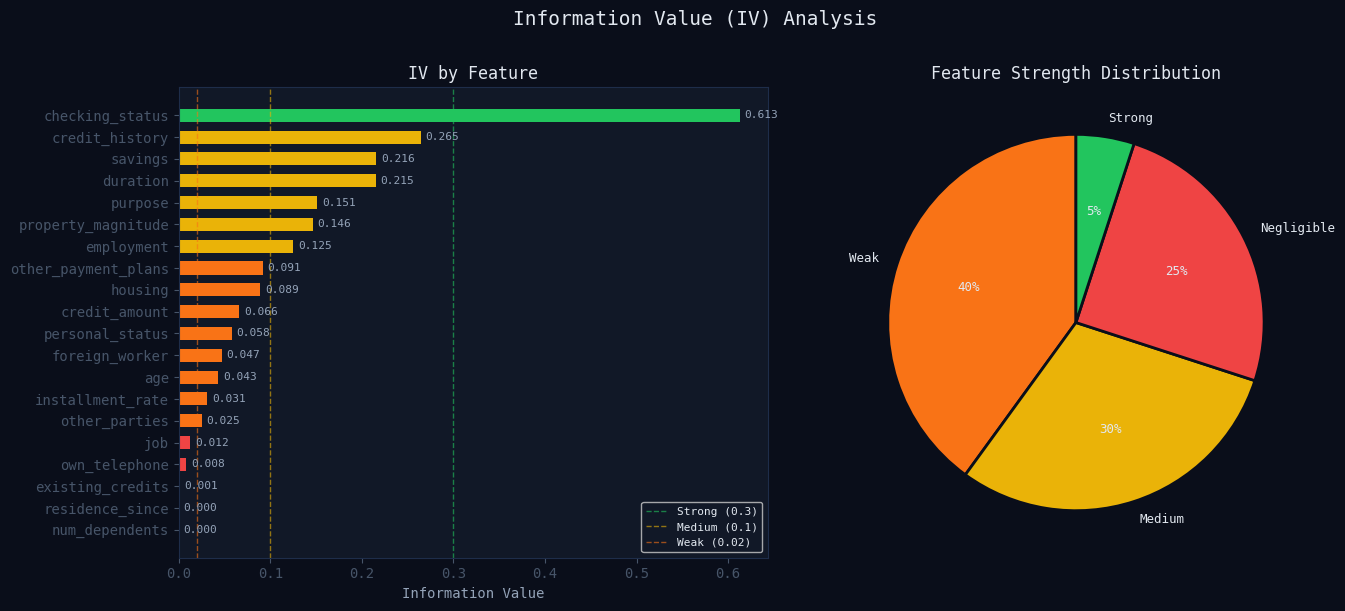


  Plotting WOE bins for top feature: checking_status
  → Saved: pd_model_outputs\02_woe_checking_status.png


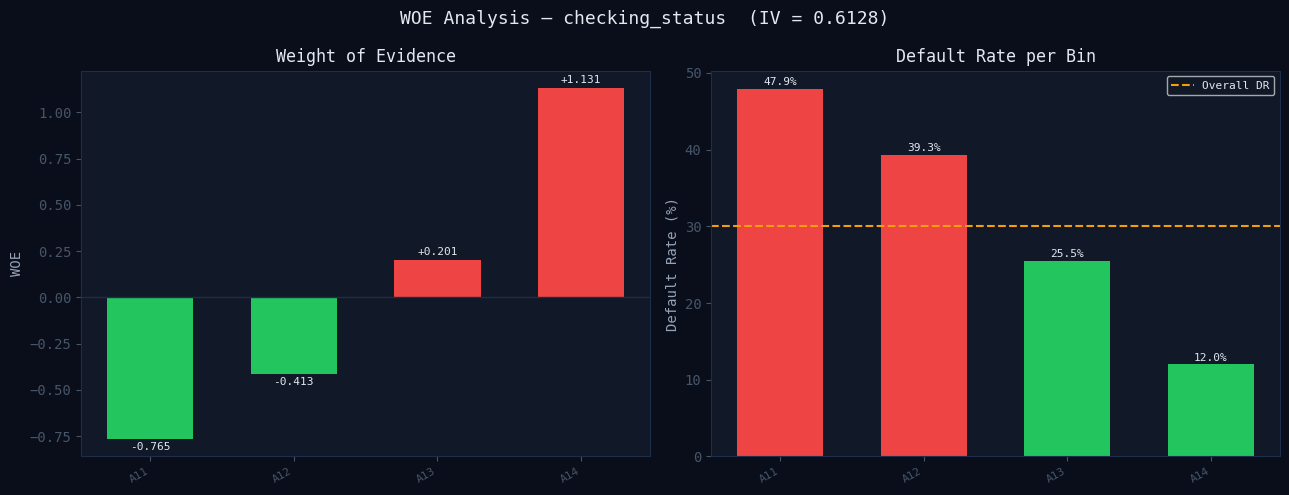


  Selected 15 WOE features (IV > 0.02)

────────────────────────────────────────────────────────────
  STEP 2: Logistic Regression (WOE-transformed)
────────────────────────────────────────────────────────────

──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
  AUC-ROC   : 0.7802  ✓ Good
  KS Stat   : 0.4595   ✓ Good
  Gini Coeff: 0.5604  ✓ Good

  Classification Report:

              precision    recall  f1-score   support

        Good      0.795     0.914     0.850       140
     Default      0.692     0.450     0.545        60

    accuracy                          0.775       200
   macro avg      0.744     0.682     0.698       200
weighted avg      0.764     0.775     0.759       200


  Top LR Coefficients:
                feature  coefficient
   installment_rate_woe    -1.320025
    personal_status_woe    -0.928191
            purpose_woe    -0.925171
           duration_woe    -0.837159
            s

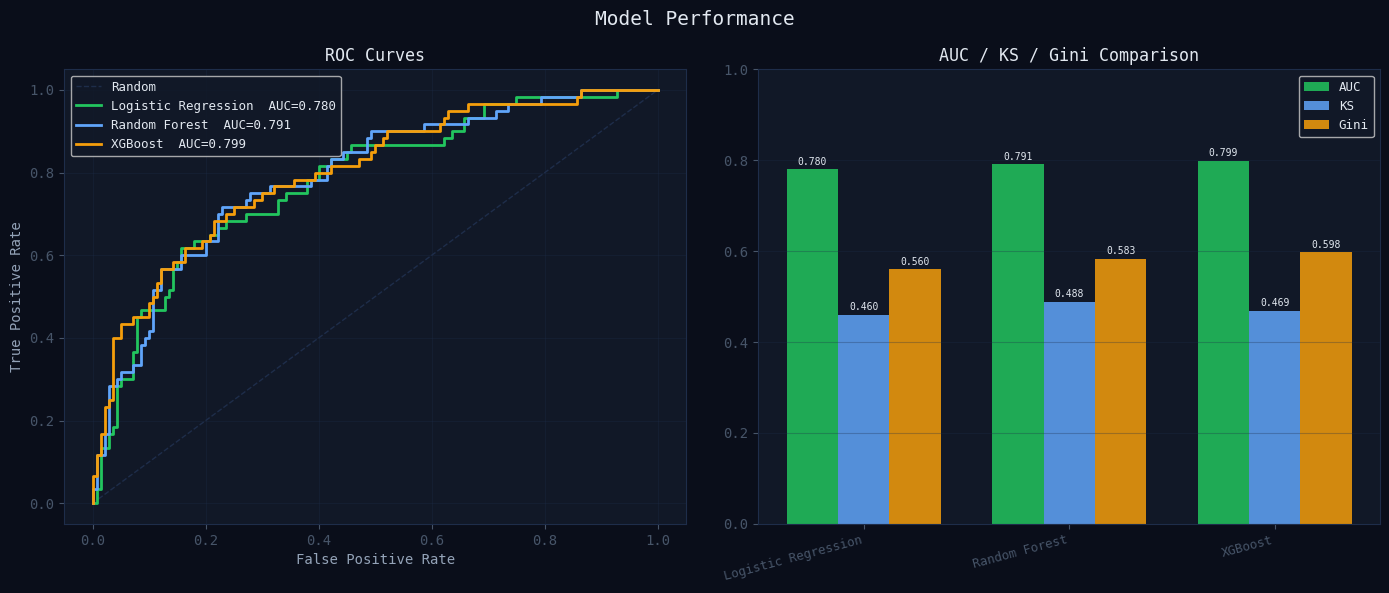

  Plotting score distributions...
  → Saved: pd_model_outputs\04_score_distribution.png


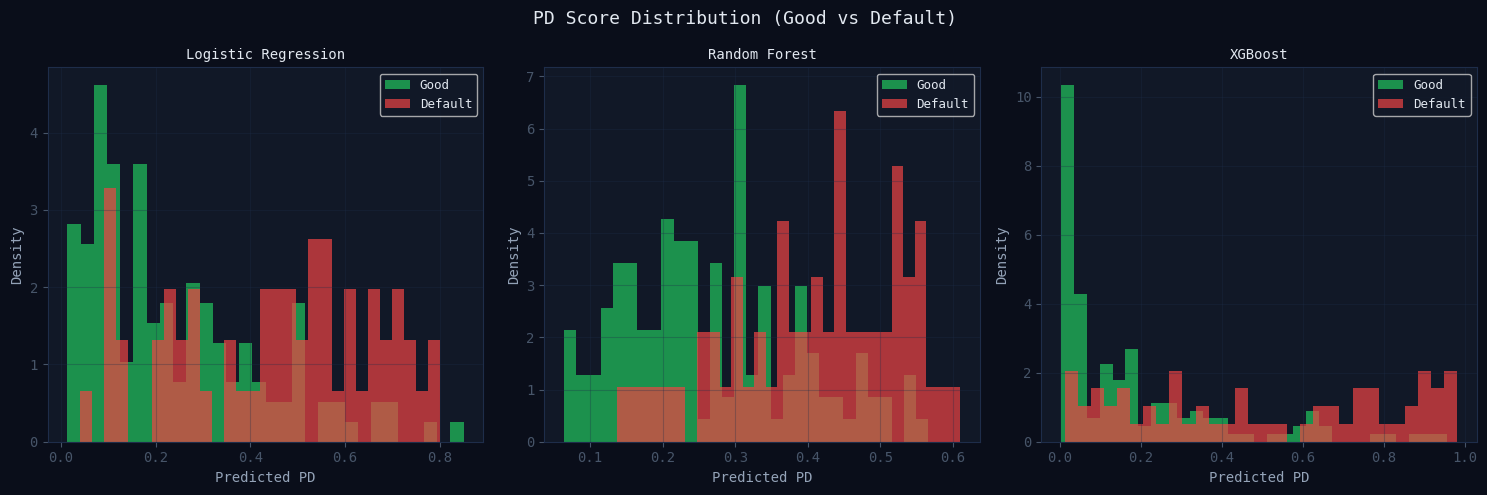

  Plotting confusion matrices...
  → Saved: pd_model_outputs\09_confusion_matrices.png


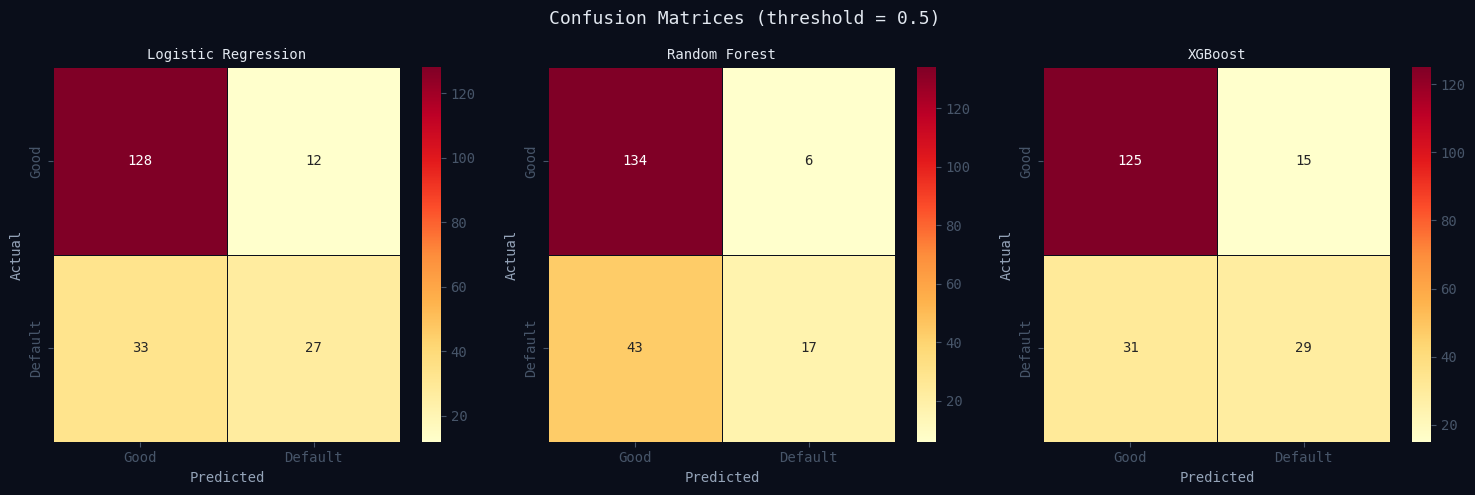

  Plotting feature importance...
  → Saved: pd_model_outputs\08_feature_importance.png


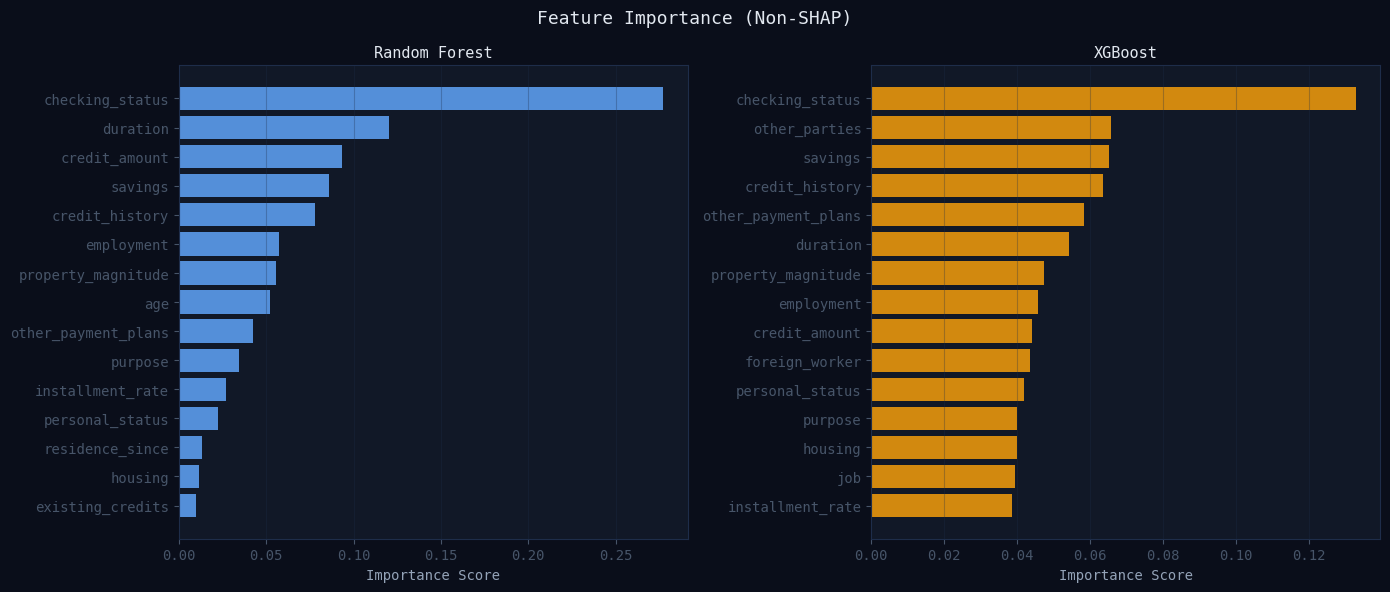


────────────────────────────────────────────────────────────
  STEP 5: SHAP Interpretability
────────────────────────────────────────────────────────────

  LR SHAP (linear explainer)...
  → Saved: pd_model_outputs\05_shap_bar_LR.png


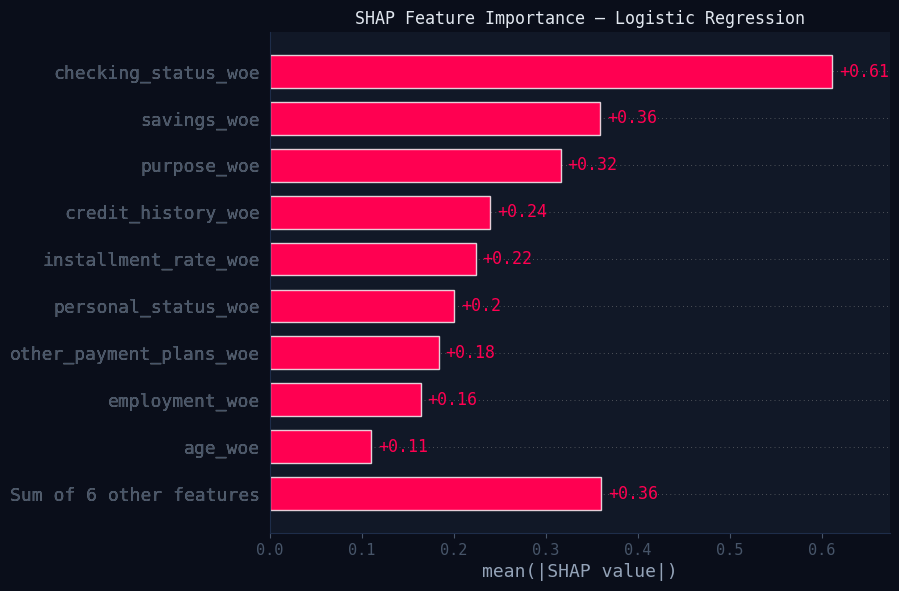


  Computing SHAP values for XGBoost...
  → Saved: pd_model_outputs\05_shap_bar_XGBoost.png
  → Saved: pd_model_outputs\06_shap_beeswarm_XGBoost.png
  → Saved: pd_model_outputs\07_shap_waterfall_XGBoost.png

════════════════════════════════════════════════════════════
  FINAL MODEL COMPARISON
════════════════════════════════════════════════════════════
              model    AUC     KS   Gini
Logistic Regression 0.7802 0.4595 0.5604
      Random Forest 0.7914 0.4881 0.5828
            XGBoost 0.7989 0.4690 0.5978

  Best AUC     : XGBoost
  Recommended  : Logistic Regression (Basel/regulatory compliance)
  Challenger   : XGBoost (highest predictive performance)

  All plots saved to: ./pd_model_outputs/
════════════════════════════════════════════════════════════



In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 5. MAIN PIPELINE
# ══════════════════════════════════════════════════════════════════════════════

def main():
    print("\n" + "═"*60)
    print("  PD MODEL — GERMAN CREDIT DATASET")
    print("═"*60)

    # ── Load data ─────────────────────────────────────────────────────────────
    df = load_german_credit()
    print(f"\n  Shape     : {df.shape}")
    print(f"  Default % : {df['target'].mean():.1%}")
    print(f"  Columns   : {list(df.columns)}")

    # ── Feature engineering ───────────────────────────────────────────────────
    CAT_FEATS = ["checking_status", "credit_history", "purpose", "savings",
                 "employment", "personal_status", "other_parties",
                 "property_magnitude", "other_payment_plans", "housing",
                 "job", "own_telephone", "foreign_worker"]
    NUM_FEATS = ["duration", "credit_amount", "installment_rate",
                 "residence_since", "age", "existing_credits", "num_dependents"]
    ALL_FEATS = CAT_FEATS + NUM_FEATS

    X = df[ALL_FEATS].copy()
    y = df["target"]

    # ── Train / test split ────────────────────────────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)
    print(f"\n  Train size: {len(X_train):,}  |  Test size: {len(X_test):,}")

    # ── WOE / IV ──────────────────────────────────────────────────────────────
    print("\n" + "─"*60)
    print("  STEP 1: WOE / IV Calculation")
    print("─"*60)

    woe = WOEEncoder(n_bins=5, min_samples=10)
    X_train_woe = woe.fit_transform(X_train, y_train)
    X_test_woe  = woe.transform(X_test)

    iv_df = woe.iv_summary()
    print(iv_df.to_string(index=False))

    # ── Plots: IV & WOE ───────────────────────────────────────────────────────
    print("\n  Plotting IV summary...")
    plot_iv_summary(iv_df)

    # WOE bins for top feature
    top_feature = iv_df.iloc[0]["feature"]
    print(f"\n  Plotting WOE bins for top feature: {top_feature}")
    plot_woe_bins(woe, top_feature, X_train, y_train)

    # ── Select features with IV > 0.02 ────────────────────────────────────────
    selected = iv_df[iv_df["iv"] > 0.02]["feature"].tolist()
    woe_cols  = [f + "_woe" for f in selected]
    woe_cols  = [c for c in woe_cols if c in X_train_woe.columns]
    X_tr  = X_train_woe[woe_cols]
    X_te  = X_test_woe[woe_cols]
    print(f"\n  Selected {len(woe_cols)} WOE features (IV > 0.02)")

    # ── Also prepare label-encoded X for RF / XGB ─────────────────────────────
    X_train_enc = X_train.copy()
    X_test_enc  = X_test.copy()
    for col in CAT_FEATS:
        le = LabelEncoder()
        X_train_enc[col] = le.fit_transform(X_train[col].astype(str))
        X_test_enc[col]  = le.transform(
            X_test[col].astype(str).map(
                lambda v: v if v in le.classes_ else le.classes_[0]))

    # ── MODEL 1: Logistic Regression (WOE features) ───────────────────────────
    print("\n" + "─"*60)
    print("  STEP 2: Logistic Regression (WOE-transformed)")
    print("─"*60)

    lr = LogisticRegression(C=1.0, solver="lbfgs", max_iter=1000, random_state=42)
    lr.fit(X_tr, y_train)
    lr_proba = lr.predict_proba(X_te)[:, 1]
    lr_pred  = (lr_proba >= 0.5).astype(int)
    lr_met   = print_metrics("Logistic Regression", y_test, lr_proba, lr_pred)

    # Coefficients
    coef_df = pd.DataFrame({
        "feature": woe_cols,
        "coefficient": lr.coef_[0]
    }).sort_values("coefficient", key=abs, ascending=False)
    print("\n  Top LR Coefficients:")
    print(coef_df.head(10).to_string(index=False))

    # MODEL 2: Random Forest #
    print("\n" + "─"*60)
    print("  STEP 3: Random Forest")
    print("─"*60)

    rf = RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_leaf=20,
        random_state=42, n_jobs=-1)
    rf.fit(X_train_enc, y_train)
    rf_proba = rf.predict_proba(X_test_enc)[:, 1]
    rf_pred  = (rf_proba >= 0.5).astype(int)
    rf_met   = print_metrics("Random Forest", y_test, rf_proba, rf_pred)

    # ── MODEL 3: XGBoost ─────────────────────────────────────────────────────
    print("\n" + "─"*60)
    print("  STEP 4: XGBoost")
    print("─"*60)

    if HAS_XGB:
        xgb = XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8,
            use_label_encoder=False, eval_metric="auc",
            random_state=42, verbosity=0)
        xgb.fit(X_train_enc, y_train,
                eval_set=[(X_test_enc, y_test)], verbose=False)
        xgb_proba = xgb.predict_proba(X_test_enc)[:, 1]
        xgb_pred  = (xgb_proba >= 0.5).astype(int)
        xgb_met   = print_metrics("XGBoost", y_test, xgb_proba, xgb_pred)
    else:
        print("  XGBoost not available — skipping.")
        xgb, xgb_proba, xgb_pred, xgb_met = None, None, None, None

    # ── Compile results ───────────────────────────────────────────────────────
    results = [
        {"name": "Logistic Regression", "proba": lr_proba,  "pred": lr_pred,  "metrics": lr_met},
        {"name": "Random Forest",       "proba": rf_proba,  "pred": rf_pred,  "metrics": rf_met},
    ]
    rf_model_for_plot, xgb_model_for_plot = rf, None
    if HAS_XGB and xgb is not None:
        results.append({"name": "XGBoost", "proba": xgb_proba, "pred": xgb_pred, "metrics": xgb_met})
        xgb_model_for_plot = xgb

    # ── Plots: ROC, scores, confusion ────────────────────────────────────────
    print("\n  Plotting ROC curves...")
    plot_roc_curves(results, y_test)

    print("  Plotting score distributions...")
    plot_score_distribution(results, y_test)

    print("  Plotting confusion matrices...")
    plot_confusion_matrices(results, y_test)

    # ── Feature importance (tree models) ─────────────────────────────────────
    print("  Plotting feature importance...")
    plot_feature_importance(rf_model_for_plot, xgb_model_for_plot,
                            list(X_train_enc.columns))

    # ── SHAP ─────────────────────────────────────────────────────────────────
    print("\n" + "─"*60)
    print(" SHAP Interpretability")
    print("─"*60)

    if HAS_SHAP:
        # LR SHAP (linear)
        print("\n  LR SHAP (linear explainer)...")
        lr_explainer = shap.LinearExplainer(lr, X_tr)
        lr_shap = lr_explainer(X_te)
        # shap.plots.bar manages its own figure — do NOT pass ax=
        plt.figure(figsize=(10, 6))
        shap.plots.bar(lr_shap, show=False)
        fig = plt.gcf()
        fig.patch.set_facecolor(COLORS["bg"])
        fig.axes[0].set_title("SHAP Feature Importance — Logistic Regression",
                               color=COLORS["text"])
        _save(fig, "05_shap_bar_LR")
        plt.show()
        plt.close()

        # XGB SHAP (tree)
        if HAS_XGB and xgb is not None:
            plot_shap_summary(xgb, X_test_enc, "XGBoost")
    else:
        print("  SHAP not installed — skipping. Run: pip install shap")

    # ── Summary table ─────────────────────────────────────────────────────────
    print("\n" + "═"*60)
    print("  FINAL MODEL COMPARISON")
    print("═"*60)
    summary = pd.DataFrame([r["metrics"] for r in results])
    print(summary.to_string(index=False))

    best = summary.loc[summary["AUC"].idxmax(), "model"]
    print(f"\n  Best AUC     : {best}")
    print(f"  Recommended  : Logistic Regression (Basel/regulatory compliance)")
    print(f"  Challenger   : XGBoost (highest predictive performance)")
    print(f"\n  All plots saved to: ./{OUTPUT_DIR}/")
    print("═"*60 + "\n")


if __name__ == "__main__":
    main()